# PCA Feature Modeling and Clustering Analysis

This notebook performs:
- Linear Regression from `PC1..PC10` to `gestation_week` and `pair_type`
- KNN regression with multiple neighbors and model selection
- K-means clustering on `PC1..PC10 + gestation_week`
- Cluster-center identification and optical flow analysis across cluster-center MRI volumes

> Note: `features_pca.csv` has 20 rows while `data/processed` has 27 `.nii.gz` files. We map row index (0..19) to the first 20 sorted files (`ses-01` to `ses-20`).


In [23]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, silhouette_score
from sklearn.decomposition import PCA

import nibabel as nib
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML

# Resolve project paths
cwd = Path.cwd().resolve()
if cwd.name == 'notebooks':
    project_root = cwd.parent.parent
elif (cwd / 'src' / 'notebooks').exists():
    project_root = cwd
else:
    project_root = cwd

src_path = project_root / 'src'
import sys
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from utils.optical_flow import compute_optical_flow

data_path = project_root / 'src' / 'notebooks' / 'features_pca.csv'
nii_dir = project_root / 'data' / 'processed'
out_dir = project_root / 'src' / 'notebooks' / 'outputs'
out_dir.mkdir(parents=True, exist_ok=True)

print(f'Project root: {project_root}')
print(f'Data CSV: {data_path}')
print(f'NIfTI dir: {nii_dir}')
print(f'Outputs: {out_dir}')


Project root: /home/tydaniel-bybruce/Documents/codes/BrainIAC
Data CSV: /home/tydaniel-bybruce/Documents/codes/BrainIAC/src/notebooks/features_pca.csv
NIfTI dir: /home/tydaniel-bybruce/Documents/codes/BrainIAC/data/processed
Outputs: /home/tydaniel-bybruce/Documents/codes/BrainIAC/src/notebooks/outputs


In [24]:
df = pd.read_csv(data_path)
pc_cols = [f'PC{i}' for i in range(1, 11)]
target_cols = ['gestation_week', 'pair_type']

assert all(c in df.columns for c in pc_cols + target_cols), 'Missing expected columns.'

# Attach NIfTI mapping by row index (first N sorted files)
nii_files = sorted(nii_dir.glob('*.nii.gz'))
if len(nii_files) < len(df):
    raise ValueError(f'Not enough NIfTI files. Need {len(df)}, found {len(nii_files)}')

mapped_files = nii_files[:len(df)]
df['nii_path'] = [str(p) for p in mapped_files]

print('Data shape:', df.shape)
display(df.head())
print('Gestation weeks:', df['gestation_week'].tolist())


Data shape: (20, 14)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,gestation_week,pair_type,label,nii_path
0,4.708132,1.258268,-9.394118,1.972974,6.762503,-1.761619,-7.920927,9.886319,-3.367754,-3.728396,9.0,0,0,/home/tydaniel-bybruce/Documents/codes/BrainIA...
1,34.529095,6.282167,-1.285135,7.092193,-0.427087,-6.920956,8.710385,6.726908,-2.283220,2.256514,12.0,1,1,/home/tydaniel-bybruce/Documents/codes/BrainIA...
2,51.736129,10.191339,-2.022224,3.475631,-0.297328,4.003473,-1.545800,-6.110235,-0.055217,1.206793,14.0,2,2,/home/tydaniel-bybruce/Documents/codes/BrainIA...
3,11.130277,2.958802,-5.048078,-15.588063,-1.275080,-5.505866,-4.031942,-4.746305,-3.128561,-5.519537,15.0,3,3,/home/tydaniel-bybruce/Documents/codes/BrainIA...
4,4.476836,-6.014513,7.120539,-4.088170,0.192205,6.808010,-0.449566,0.561759,4.047843,-2.729852,17.0,4,4,/home/tydaniel-bybruce/Documents/codes/BrainIA...


Gestation weeks: [9.0, 12.0, 14.0, 15.0, 17.0, 19.0, 22.0, 24.0, 27.0, 29.0, 31.0, 33.0, 36.0, 43.0, 46.0, 49.0, 51.0, 68.0, 93.0, 162.0]


In [25]:
X = df[pc_cols].values
y = df[target_cols].values

# -------------------------
# Linear Regression
# -------------------------
lr = LinearRegression()
lr.fit(X, y)
y_pred_lr = lr.predict(X)

lr_metrics = {
    'R2_gestation_week': r2_score(y[:, 0], y_pred_lr[:, 0]),
    'R2_pair_type': r2_score(y[:, 1], y_pred_lr[:, 1]),
    'MAE_gestation_week': mean_absolute_error(y[:, 0], y_pred_lr[:, 0]),
    'MAE_pair_type': mean_absolute_error(y[:, 1], y_pred_lr[:, 1]),
    'RMSE_gestation_week': np.sqrt(mean_squared_error(y[:, 0], y_pred_lr[:, 0])),
    'RMSE_pair_type': np.sqrt(mean_squared_error(y[:, 1], y_pred_lr[:, 1])),
}

print('Linear Regression fitting result:')
for k, v in lr_metrics.items():
    print(f'  {k}: {v:.4f}')

df_lr = df.copy()
df_lr['pred_gestation_week_lr'] = y_pred_lr[:, 0]
df_lr['pred_pair_type_lr'] = y_pred_lr[:, 1]

display(df_lr[['label', 'gestation_week', 'pred_gestation_week_lr', 'pair_type', 'pred_pair_type_lr']].head(10))


Linear Regression fitting result:
  R2_gestation_week: 0.7216
  R2_pair_type: 0.8325
  MAE_gestation_week: 13.8349
  MAE_pair_type: 1.6225
  RMSE_gestation_week: 18.1841
  RMSE_pair_type: 2.3600


,label,gestation_week,pred_gestation_week_lr,pair_type,pred_pair_type_lr
0,0,9.0,9.515059,0,-0.711532
1,1,12.0,16.282382,1,3.429252
2,2,14.0,18.407940,2,1.602237
3,3,15.0,-0.230428,3,2.304741
4,4,17.0,43.797084,4,10.635796
5,5,19.0,27.421586,5,5.889061
6,6,22.0,31.445055,6,7.342234
7,7,24.0,12.515641,7,8.671140
8,8,27.0,19.329516,8,7.470070
9,9,29.0,31.712814,9,8.975655


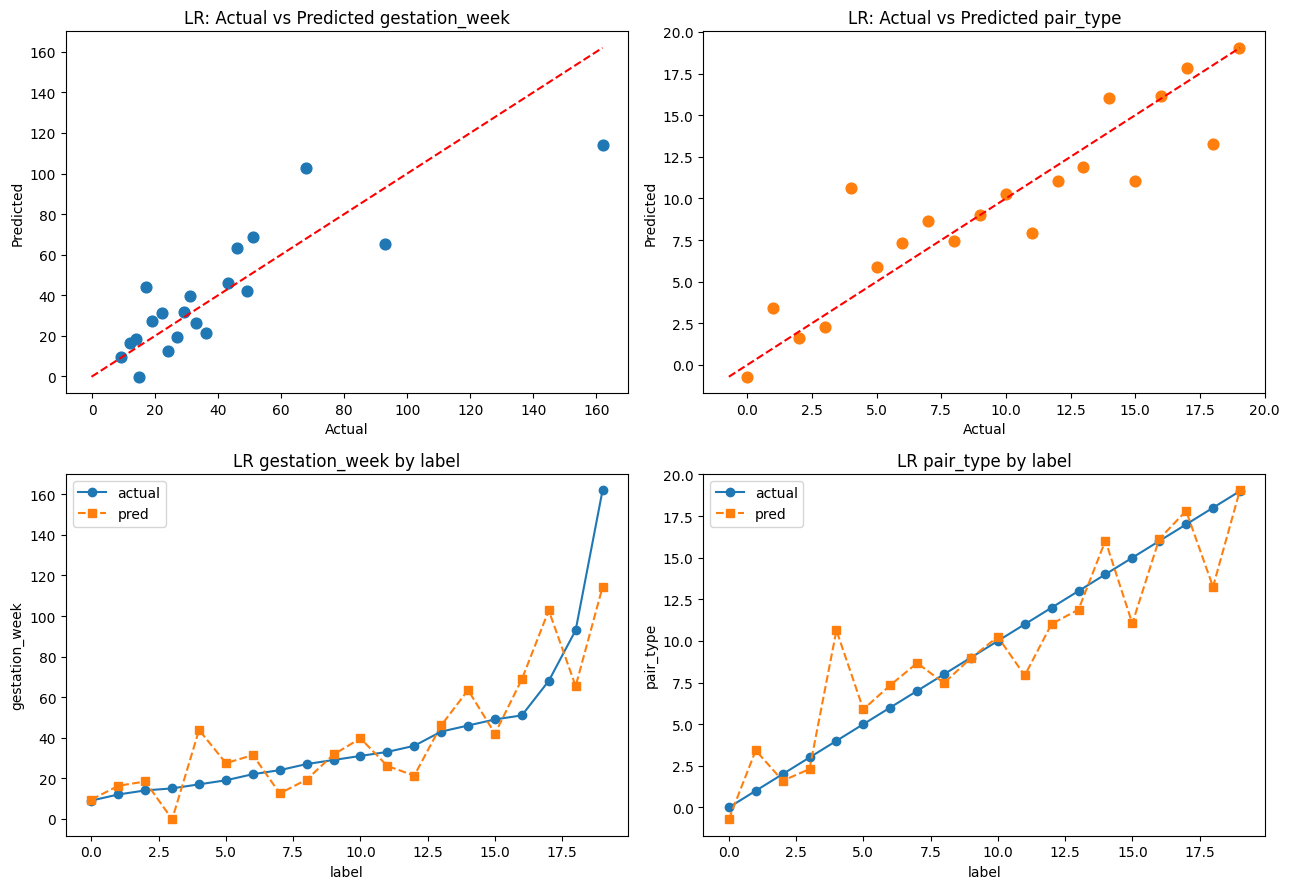

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# actual vs predicted for gestation_week
axes[0, 0].scatter(df['gestation_week'], df_lr['pred_gestation_week_lr'], s=60)
mn = min(df['gestation_week'].min(), df_lr['pred_gestation_week_lr'].min())
mx = max(df['gestation_week'].max(), df_lr['pred_gestation_week_lr'].max())
axes[0, 0].plot([mn, mx], [mn, mx], 'r--')
axes[0, 0].set_title('LR: Actual vs Predicted gestation_week')
axes[0, 0].set_xlabel('Actual')
axes[0, 0].set_ylabel('Predicted')

# actual vs predicted for pair_type
axes[0, 1].scatter(df['pair_type'], df_lr['pred_pair_type_lr'], s=60, color='tab:orange')
mn = min(df['pair_type'].min(), df_lr['pred_pair_type_lr'].min())
mx = max(df['pair_type'].max(), df_lr['pred_pair_type_lr'].max())
axes[0, 1].plot([mn, mx], [mn, mx], 'r--')
axes[0, 1].set_title('LR: Actual vs Predicted pair_type')
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')

# by label index (non-even gestation steps visible)
axes[1, 0].plot(df['label'], df['gestation_week'], 'o-', label='actual')
axes[1, 0].plot(df['label'], df_lr['pred_gestation_week_lr'], 's--', label='pred')
axes[1, 0].set_title('LR gestation_week by label')
axes[1, 0].set_xlabel('label')
axes[1, 0].set_ylabel('gestation_week')
axes[1, 0].legend()

axes[1, 1].plot(df['label'], df['pair_type'], 'o-', label='actual')
axes[1, 1].plot(df['label'], df_lr['pred_pair_type_lr'], 's--', label='pred')
axes[1, 1].set_title('LR pair_type by label')
axes[1, 1].set_xlabel('label')
axes[1, 1].set_ylabel('pair_type')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


In [27]:
# -------------------------
# KNN Regression with multiple neighbors
# -------------------------
neighbor_values = [1, 2, 3, 4, 5, 6, 7, 8, 9]
knn_results = []
knn_predictions = {}

for k in neighbor_values:
    model = MultiOutputRegressor(
        Pipeline([
            ('scaler', StandardScaler()),
            ('knn', KNeighborsRegressor(n_neighbors=k, weights='distance'))
        ])
    )
    model.fit(X, y)
    pred = model.predict(X)
    knn_predictions[k] = pred

    rmse_gw = np.sqrt(mean_squared_error(y[:, 0], pred[:, 0]))
    rmse_pt = np.sqrt(mean_squared_error(y[:, 1], pred[:, 1]))
    r2_gw = r2_score(y[:, 0], pred[:, 0])
    r2_pt = r2_score(y[:, 1], pred[:, 1])
    knn_results.append({
        'k': k,
        'RMSE_gestation_week': rmse_gw,
        'RMSE_pair_type': rmse_pt,
        'R2_gestation_week': r2_gw,
        'R2_pair_type': r2_pt,
        'score_sum_rmse': rmse_gw + rmse_pt
    })

knn_df = pd.DataFrame(knn_results).sort_values('score_sum_rmse').reset_index(drop=True)
display(knn_df)

best_k = int(knn_df.loc[0, 'k'])
print(f'Best k (by sum RMSE): {best_k}')

best_knn_pred = knn_predictions[best_k]
df_knn = df.copy()
df_knn['pred_gestation_week_knn'] = best_knn_pred[:, 0]
df_knn['pred_pair_type_knn'] = best_knn_pred[:, 1]


,k,RMSE_gestation_week,RMSE_pair_type,R2_gestation_week,R2_pair_type,score_sum_rmse
0,1,0.0,0.0,1.0,1.0,0.0
1,2,0.0,0.0,1.0,1.0,0.0
2,3,0.0,0.0,1.0,1.0,0.0
3,4,0.0,0.0,1.0,1.0,0.0
4,5,0.0,0.0,1.0,1.0,0.0
5,6,0.0,0.0,1.0,1.0,0.0
6,7,0.0,0.0,1.0,1.0,0.0
7,8,0.0,0.0,1.0,1.0,0.0
8,9,0.0,0.0,1.0,1.0,0.0


Best k (by sum RMSE): 1


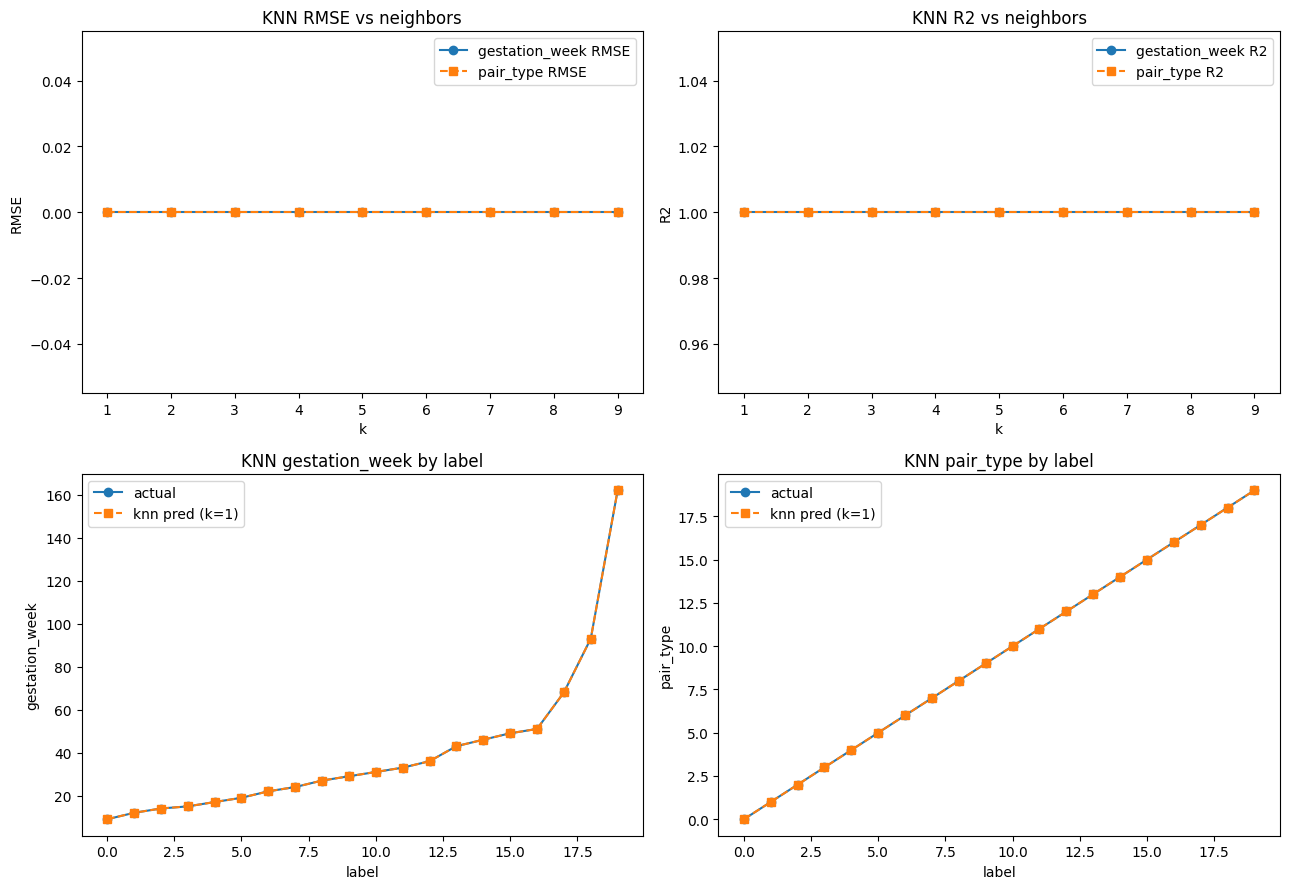

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(knn_df['k'], knn_df['RMSE_gestation_week'], 'o-', label='gestation_week RMSE')
axes[0, 0].plot(knn_df['k'], knn_df['RMSE_pair_type'], 's--', label='pair_type RMSE')
axes[0, 0].set_title('KNN RMSE vs neighbors')
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].legend()

axes[0, 1].plot(knn_df['k'], knn_df['R2_gestation_week'], 'o-', label='gestation_week R2')
axes[0, 1].plot(knn_df['k'], knn_df['R2_pair_type'], 's--', label='pair_type R2')
axes[0, 1].set_title('KNN R2 vs neighbors')
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('R2')
axes[0, 1].legend()

axes[1, 0].plot(df['label'], df['gestation_week'], 'o-', label='actual')
axes[1, 0].plot(df['label'], df_knn['pred_gestation_week_knn'], 's--', label=f'knn pred (k={best_k})')
axes[1, 0].set_title('KNN gestation_week by label')
axes[1, 0].set_xlabel('label')
axes[1, 0].set_ylabel('gestation_week')
axes[1, 0].legend()

axes[1, 1].plot(df['label'], df['pair_type'], 'o-', label='actual')
axes[1, 1].plot(df['label'], df_knn['pred_pair_type_knn'], 's--', label=f'knn pred (k={best_k})')
axes[1, 1].set_title('KNN pair_type by label')
axes[1, 1].set_xlabel('label')
axes[1, 1].set_ylabel('pair_type')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


In [29]:
# -------------------------
# KMeans clustering on PC1..PC10 + gestation_week
# -------------------------
cluster_features = pc_cols + ['gestation_week']
Xc = df[cluster_features].values

scaler_c = StandardScaler()
Xc_scaled = scaler_c.fit_transform(Xc)

k_values = list(range(2, 8))
km_scores = []
km_models = {}

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_k = km.fit_predict(Xc_scaled)
    sil = silhouette_score(Xc_scaled, labels_k)
    inertia = km.inertia_
    km_scores.append({'k': k, 'silhouette': sil, 'inertia': inertia})
    km_models[k] = (km, labels_k)

km_eval_df = pd.DataFrame(km_scores).sort_values('silhouette', ascending=False).reset_index(drop=True)
display(km_eval_df)

best_km_k = int(km_eval_df.loc[0, 'k'])
km_best, clabels = km_models[best_km_k]
df_cluster = df.copy()
df_cluster['cluster'] = clabels

print(f'Best KMeans clusters by silhouette: {best_km_k}')
print(df_cluster[['label', 'gestation_week', 'pair_type', 'cluster']].sort_values('cluster').to_string(index=False))


,k,silhouette,inertia
0,7,0.106542,107.980941
1,2,0.092467,192.529610
2,5,0.087166,140.187175
3,6,0.082840,124.220192
4,4,0.074626,157.300944
5,3,0.055513,176.393490


Best KMeans clusters by silhouette: 7
 label  gestation_week  pair_type  cluster
     1            12.0          1        0
     2            14.0          2        0
    15            49.0         15        1
    14            46.0         14        1
     0             9.0          0        2
     5            19.0          5        2
    10            31.0         10        2
     4            17.0          4        3
     8            27.0          8        3
    18            93.0         18        3
    11            33.0         11        3
    12            36.0         12        3
    17            68.0         17        4
    19           162.0         19        4
     7            24.0          7        5
    16            51.0         16        5
    13            43.0         13        5
     9            29.0          9        5
     6            22.0          6        6
     3            15.0          3        6


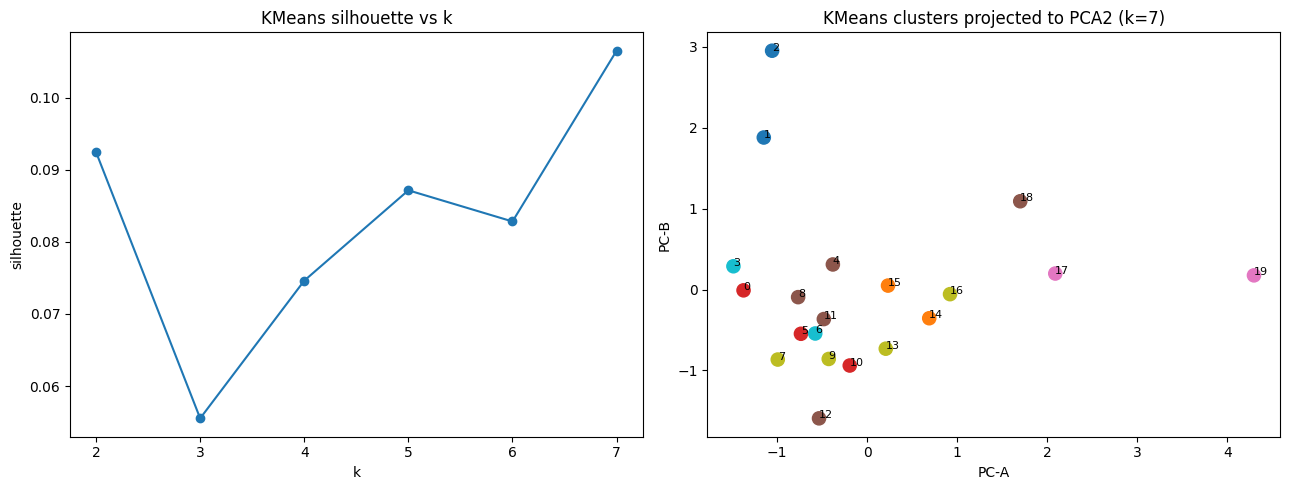

In [30]:
# 2D visualization via PCA projection
pca2 = PCA(n_components=2, random_state=42)
proj = pca2.fit_transform(Xc_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(pd.DataFrame(km_scores)['k'], pd.DataFrame(km_scores)['silhouette'], 'o-')
axes[0].set_title('KMeans silhouette vs k')
axes[0].set_xlabel('k')
axes[0].set_ylabel('silhouette')

scatter = axes[1].scatter(proj[:, 0], proj[:, 1], c=clabels, s=90, cmap='tab10')
for i, row in df_cluster.iterrows():
    axes[1].text(proj[i, 0], proj[i, 1], str(int(row['label'])), fontsize=8)
axes[1].set_title(f'KMeans clusters projected to PCA2 (k={best_km_k})')
axes[1].set_xlabel('PC-A')
axes[1].set_ylabel('PC-B')

plt.tight_layout()
plt.show()


In [31]:
# -------------------------
# Find most central data point in each cluster
# -------------------------
centers_scaled = km_best.cluster_centers_

center_rows = []
for c in sorted(df_cluster['cluster'].unique()):
    idx = np.where(clabels == c)[0]
    points = Xc_scaled[idx]
    dists = np.linalg.norm(points - centers_scaled[c], axis=1)
    local_best = idx[np.argmin(dists)]
    center_rows.append({
        'cluster': int(c),
        'row_index': int(local_best),
        'label': int(df_cluster.loc[local_best, 'label']),
        'gestation_week': float(df_cluster.loc[local_best, 'gestation_week']),
        'pair_type': int(df_cluster.loc[local_best, 'pair_type']),
        'nii_path': df_cluster.loc[local_best, 'nii_path'],
        'distance_to_centroid': float(np.min(dists)),
    })

center_df = pd.DataFrame(center_rows).sort_values('gestation_week').reset_index(drop=True)
print('Most central data points per cluster (sorted by gestation_week):')
display(center_df)


Most central data points per cluster (sorted by gestation_week):


,cluster,row_index,label,gestation_week,pair_type,nii_path,distance_to_centroid
0,0,1,1,12.0,1,/home/tydaniel-bybruce/Documents/codes/BrainIA...,2.396087
1,6,3,3,15.0,3,/home/tydaniel-bybruce/Documents/codes/BrainIA...,1.800946
2,3,4,4,17.0,4,/home/tydaniel-bybruce/Documents/codes/BrainIA...,1.585816
3,2,10,10,31.0,10,/home/tydaniel-bybruce/Documents/codes/BrainIA...,1.955878
4,1,14,14,46.0,14,/home/tydaniel-bybruce/Documents/codes/BrainIA...,1.347888
5,5,16,16,51.0,16,/home/tydaniel-bybruce/Documents/codes/BrainIA...,1.898045
6,4,17,17,68.0,17,/home/tydaniel-bybruce/Documents/codes/BrainIA...,1.443871


In [32]:
# -------------------------
# Optical flow between consecutive cluster-center volumes
# Interactive slice visualization saved as HTML files
# -------------------------

def load_volume(path):
    vol = nib.load(path).get_fdata()
    vol = np.nan_to_num(vol)
    return vol.astype(np.float32)


def normalize_slice(slc):
    lo, hi = np.percentile(slc, [1, 99])
    if hi <= lo:
        hi = lo + 1.0
    arr = np.clip((slc - lo) / (hi - lo), 0, 1)
    return (arr * 255).astype(np.uint8)


def build_flow_figure(vol1, vol2, title='Optical flow by slice'):
    ns = min(vol1.shape[2], vol2.shape[2])
    mag_stack = []
    s1_stack = []
    s2_stack = []

    for z in range(ns):
        s1 = normalize_slice(vol1[:, :, z])
        s2 = normalize_slice(vol2[:, :, z])
        flow, _ = compute_optical_flow(s1, s2, method='farneback')
        mag = np.sqrt(flow[..., 0] ** 2 + flow[..., 1] ** 2)
        s1_stack.append(s1)
        s2_stack.append(s2)
        mag_stack.append(mag)

    fig = make_subplots(rows=1, cols=3, subplot_titles=['Volume A', 'Volume B', 'Flow magnitude'])

    fig.add_trace(go.Heatmap(z=s1_stack[0], colorscale='gray', showscale=False), row=1, col=1)
    fig.add_trace(go.Heatmap(z=s2_stack[0], colorscale='gray', showscale=False), row=1, col=2)
    fig.add_trace(go.Heatmap(z=mag_stack[0], colorscale='Turbo', showscale=True, colorbar=dict(title='|flow|')), row=1, col=3)

    frames = []
    for z in range(ns):
        frames.append(go.Frame(
            data=[
                go.Heatmap(z=s1_stack[z], colorscale='gray', showscale=False),
                go.Heatmap(z=s2_stack[z], colorscale='gray', showscale=False),
                go.Heatmap(z=mag_stack[z], colorscale='Turbo', showscale=True, colorbar=dict(title='|flow|')),
            ],
            name=str(z)
        ))

    fig.frames = frames

    steps = [
        dict(method='animate',
             args=[[str(z)], {'mode': 'immediate', 'frame': {'duration': 0, 'redraw': True}, 'transition': {'duration': 0}}],
             label=str(z))
        for z in range(ns)
    ]

    fig.update_layout(
        title=title,
        sliders=[dict(active=0, currentvalue={'prefix': 'Slice: '}, steps=steps)],
        updatemenus=[dict(
            type='buttons',
            buttons=[
                dict(label='Play', method='animate', args=[None, {'frame': {'duration': 120, 'redraw': True}, 'fromcurrent': True}]),
                dict(label='Pause', method='animate', args=[[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate'}]),
            ],
            direction='left', x=0.1, y=1.15
        )],
        width=1300,
        height=450
    )
    return fig

center_paths = center_df['nii_path'].tolist()
center_labels = center_df['label'].tolist()

flow_outputs = []
for i in range(len(center_paths) - 1):
    p1 = center_paths[i]
    p2 = center_paths[i + 1]
    l1 = center_labels[i]
    l2 = center_labels[i + 1]
    v1 = load_volume(p1)
    v2 = load_volume(p2)

    fig = build_flow_figure(v1, v2, title=f'Optical Flow: center label {l1} -> {l2}')
    html_path = out_dir / f'optical_flow_center_{l1}_to_{l2}.html'
    fig.write_html(html_path)
    flow_outputs.append(str(html_path))

print('Generated optical-flow HTML files:')
for fp in flow_outputs:
    print(' ', fp)



Generated optical-flow HTML files:
  /home/tydaniel-bybruce/Documents/codes/BrainIAC/src/notebooks/outputs/optical_flow_center_1_to_3.html
  /home/tydaniel-bybruce/Documents/codes/BrainIAC/src/notebooks/outputs/optical_flow_center_3_to_4.html
  /home/tydaniel-bybruce/Documents/codes/BrainIAC/src/notebooks/outputs/optical_flow_center_4_to_10.html
  /home/tydaniel-bybruce/Documents/codes/BrainIAC/src/notebooks/outputs/optical_flow_center_10_to_14.html
  /home/tydaniel-bybruce/Documents/codes/BrainIAC/src/notebooks/outputs/optical_flow_center_14_to_16.html
  /home/tydaniel-bybruce/Documents/codes/BrainIAC/src/notebooks/outputs/optical_flow_center_16_to_17.html


In [33]:
# Save result tables for external use
lr_out = out_dir / 'lr_predictions.csv'
knn_out = out_dir / 'knn_predictions_best_k.csv'
cluster_out = out_dir / 'cluster_centers.csv'

pd.DataFrame({
    'label': df['label'],
    'actual_gestation_week': y[:, 0],
    'pred_gestation_week_lr': y_pred_lr[:, 0],
    'actual_pair_type': y[:, 1],
    'pred_pair_type_lr': y_pred_lr[:, 1],
}).to_csv(lr_out, index=False)

pd.DataFrame({
    'label': df['label'],
    'actual_gestation_week': y[:, 0],
    'pred_gestation_week_knn': best_knn_pred[:, 0],
    'actual_pair_type': y[:, 1],
    'pred_pair_type_knn': best_knn_pred[:, 1],
    'best_k': best_k,
}).to_csv(knn_out, index=False)

center_df.to_csv(cluster_out, index=False)

print('Saved:')
print(' ', lr_out)
print(' ', knn_out)
print(' ', cluster_out)


Saved:
  /home/tydaniel-bybruce/Documents/codes/BrainIAC/src/notebooks/outputs/lr_predictions.csv
  /home/tydaniel-bybruce/Documents/codes/BrainIAC/src/notebooks/outputs/knn_predictions_best_k.csv
  /home/tydaniel-bybruce/Documents/codes/BrainIAC/src/notebooks/outputs/cluster_centers.csv
